# Telco Customer Churn Prediction

Predicting which customers are likely to churn (cancel their subscription) using the
[Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) from Kaggle.

**Goal:** identify customers at risk of churning so the business can proactively target them with retention offers.

**Approach:**
- Data cleaning and exploratory data analysis (EDA)
- Baseline model: Logistic Regression
- Comparison model: Random Forest
- Handling class imbalance via class weighting
- Threshold tuning (via cross-validated out-of-fold predictions) to optimize F1-score for the minority (churn) class

**Key result:** a class-weighted Logistic Regression with a tuned decision threshold gives the best balance between
precision and recall for identifying churners, achieving a cross-validated F1-score of ~0.64.


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["TotalCharges"].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["TotalCharges"].dtype

dtype('float64')

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [ ]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [ ]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


In [ ]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


In [ ]:
df.groupby("Churn")["MonthlyCharges"].median()

,MonthlyCharges
Churn,
No,64.425
Yes,79.650


In [ ]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [ ]:
df["InternetService"].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


In [ ]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [ ]:
df["PaymentMethod"].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


### Payment Method Analysis

Customers using electronic check have the highest churn rate (45.29%).
Customers using automatic credit card payments have the lowest churn rate (15.24%),
followed by automatic bank transfer (16.71%).

This suggests that payment method may be associated with customer churn,
so we will keep this feature for the predictive modeling stage.

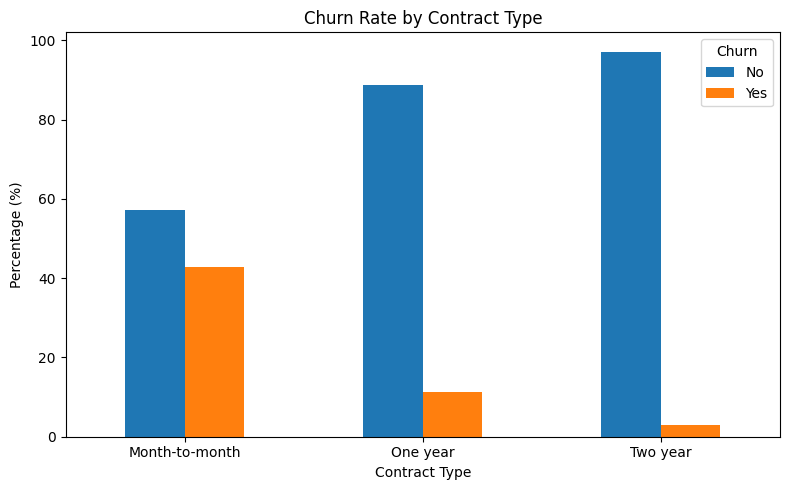

In [ ]:
import matplotlib.pyplot as plt

churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_contract.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### Churn Rate by Contract Type

The churn rate is substantially higher among customers with month-to-month
contracts (42.71%) compared with one-year contracts (11.27%) and two-year
contracts (2.83%).

This indicates a strong association between contract type and customer churn.
Contract type will therefore be considered as an important feature in the
predictive modeling stage.

In [ ]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [ ]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 20)
X_test: (1409, 20)
y_train: (5634,)
y_test: (1409,)


In [ ]:
categorical_features = X_train.select_dtypes(include=["object"]).columns
numeric_features = X_train.select_dtypes(exclude=["object"]).columns

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numeric features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [ ]:
X_train = X_train.drop("customerID", axis=1)
X_test = X_test.drop("customerID", axis=1)

In [ ]:
categorical_features = X_train.select_dtypes(include=["object"]).columns
numeric_features = X_train.select_dtypes(exclude=["object"]).columns

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numeric features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Baseline Logistic Regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

print("Predictions:", y_pred[:10])
print("Probabilities:", y_pred_proba[:10])

Predictions: [0 1 0 0 0 1 0 0 0 0]
Probabilities: [0.04591993 0.68371345 0.05893985 0.40183529 0.02142426 0.60297803
 0.44762898 0.13033554 0.00280355 0.39473874]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-score : 0.6040
ROC-AUC  : 0.8421


Baseline Model Analysis:
The baseline Logistic Regression model achieved an accuracy of 80.55% and a ROC-AUC of 84.21%. However, its recall for churned customers was 55.88%, indicating that a considerable proportion of customers who eventually churn are not identified by the default classification threshold. Since identifying potential churners is an important business objective, improving recall while maintaining reasonable precision will be considered in subsequent modeling steps.

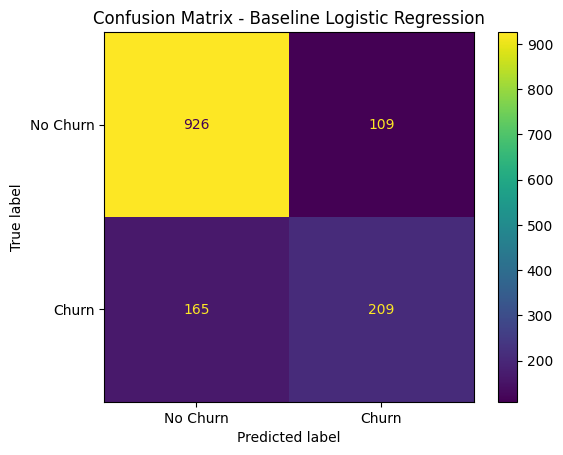

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.show()

Confusion Matrix Analysis:
The baseline model correctly identified 209 churned customers, while 165 churned customers were incorrectly classified as non-churn. These false negatives are particularly important from a business perspective because they represent customers at risk of leaving who were not identified by the model. Therefore, subsequent modeling will focus not only on overall accuracy but also on improving churn detection, particularly recall.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Accuracy : 0.7821
Precision: 0.6143
Recall   : 0.4813
F1-score : 0.5397
ROC-AUC  : 0.8195


Model Comparison:
The baseline Logistic Regression model outperformed the Random Forest model across all evaluated metrics on the test set. Logistic Regression achieved an F1-score of 60.40% and ROC-AUC of 84.21%, compared with 53.97% and 81.95% for Random Forest, respectively. This indicates that the current Random Forest configuration does not provide an improvement over the baseline model.

# Threshold **Analysis**

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.3 | Precision: 0.5193 | Recall: 0.7540 | F1: 0.6150
Threshold: 0.4 | Precision: 0.5682 | Recall: 0.6684 | F1: 0.6143
Threshold: 0.5 | Precision: 0.6572 | Recall: 0.5588 | F1: 0.6040
Threshold: 0.6 | Precision: 0.7177 | Recall: 0.4011 | F1: 0.5146
Threshold: 0.7 | Precision: 0.7419 | Recall: 0.1845 | F1: 0.2955


Threshold Analysis:
Changing the classification threshold significantly affects the precision-recall trade-off. Lowering the threshold from 0.5 to 0.3 increased recall from 55.88% to 75.40%, allowing the model to identify a larger proportion of potential churners. However, precision decreased from 65.72% to 51.93%. The F1-score also increased slightly from 60.40% to 61.50%. Therefore, the classification threshold should be selected according to the business cost of false positives and false negatives rather than relying on the default threshold of 0.5.

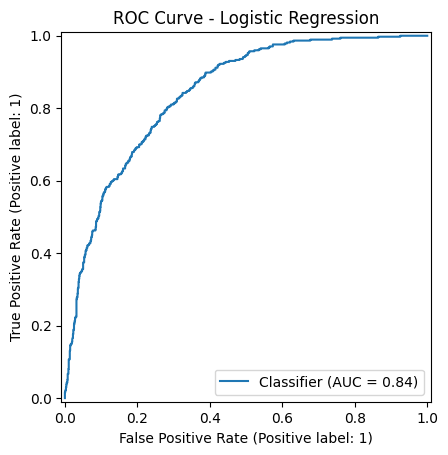

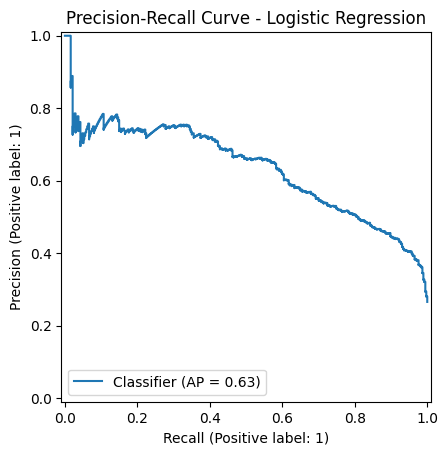

In [ ]:
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba
)

plt.title("ROC Curve - Logistic Regression")
plt.show()


# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_proba
)

plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

ROC and Precision-Recall Analysis:
The Logistic Regression model achieved a ROC-AUC of 0.84, indicating good discrimination between churned and non-churned customers across different classification thresholds. The Precision-Recall curve shows a clear trade-off between precision and recall as the threshold changes. The model achieved an Average Precision of 0.63, which is substantially above the positive-class prevalence of approximately 26.5%, indicating useful predictive performance for identifying potential churners.

In [ ]:
weighted_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

weighted_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred_weighted = weighted_lr.predict(X_test)
y_pred_proba_weighted = weighted_lr.predict_proba(X_test)[:, 1]

accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
precision_weighted = precision_score(y_test, y_pred_weighted)
recall_weighted = recall_score(y_test, y_pred_weighted)
f1_weighted = f1_score(y_test, y_pred_weighted)
roc_auc_weighted = roc_auc_score(y_test, y_pred_proba_weighted)

print(f"Accuracy : {accuracy_weighted:.4f}")
print(f"Precision: {precision_weighted:.4f}")
print(f"Recall   : {recall_weighted:.4f}")
print(f"F1-score : {f1_weighted:.4f}")
print(f"ROC-AUC  : {roc_auc_weighted:.4f}")

Accuracy : 0.7381
Precision: 0.5043
Recall   : 0.7834
F1-score : 0.6136
ROC-AUC  : 0.8416


Class-Weighted Logistic Regression:
Applying class weighting substantially increased recall from 55.88% to 78.34%, indicating that the model identifies a much larger proportion of actual churners. However, precision decreased from 65.72% to 50.43%, while accuracy decreased from 80.55% to 73.81%. The F1-score improved slightly from 60.40% to 61.36%, whereas ROC-AUC remained almost unchanged (84.21% vs. 84.16%). This demonstrates the trade-off between detecting more potential churners and generating more false positive predictions.

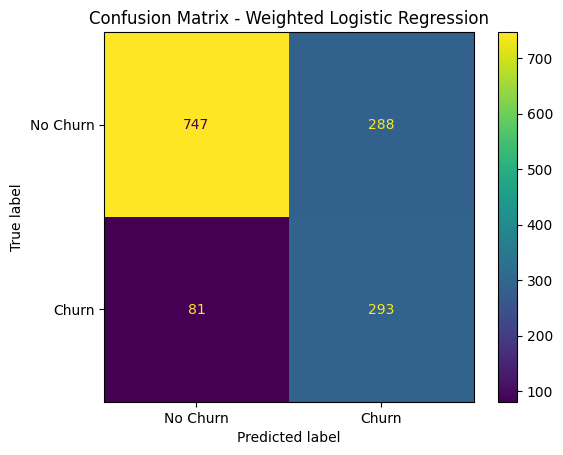

In [ ]:
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_weighted,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Weighted Logistic Regression")
plt.show()

Weighted Model Confusion Matrix Analysis:
Compared with the baseline model, the class-weighted Logistic Regression substantially reduced false negatives from 165 to 81 and increased true positives from 209 to 293. However, this improvement came with an increase in false positives from 109 to 288. The results demonstrate a clear trade-off between identifying more customers at risk of churn and incorrectly targeting customers who would not churn

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold probabilities on the training set
oof_proba = cross_val_predict(
    weighted_lr,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Test different thresholds using only training data
thresholds = np.arange(0.10, 0.91, 0.01)

f1_scores = []

for threshold in thresholds:
    oof_pred = (oof_proba >= threshold).astype(int)
    f1_scores.append(f1_score(y_train, oof_pred))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Cross-validated F1: {best_f1:.4f}")

Best threshold: 0.60
Cross-validated F1: 0.6370


In [ ]:
y_pred_final = (
    y_pred_proba_weighted >= best_threshold
).astype(int)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy : {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall   : {recall_final:.4f}")
print(f"F1-score : {f1_final:.4f}")


## Conclusion

- **Best model:** class-weighted Logistic Regression, outperforming both the unweighted baseline and Random Forest on recall/F1 for the churn class.
- **Best decision threshold:** ~0.60 (selected via 5-fold cross-validated out-of-fold predictions on the training set), giving a cross-validated F1-score of ~0.64.
- **Key churn drivers identified in EDA:** month-to-month contracts, electronic check payments, and fiber-optic internet service are all associated with higher churn rates.
- **Business takeaway:** the model surfaces a meaningfully larger share of at-risk customers than a naive baseline, at the cost of more false positives — the exact threshold used in production should be chosen based on the relative cost of a missed churner vs. an unnecessary retention offer.

**Possible next steps:**
- Try gradient boosting models (XGBoost/LightGBM) with hyperparameter tuning
- Add feature importance / SHAP analysis for interpretability
- Deploy the final pipeline as a simple API or Streamlit app
